In [159]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [160]:
skolky_venkov = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_venkov.parquet")
skolky_mesto = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_mesto.parquet")

skolky_body = pd.concat(
    [skolky_venkov, skolky_mesto]
)
skolky_body=skolky_body.drop(columns=["index_right"])

In [161]:
kraje_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/kraje.geojson")
kraje_polygony = kraje_polygony.to_crs(5514)

In [162]:
obce_polygony = gpd.read_file("geometrie/OBCE_SILC.shp").to_crs(5514)
obce_polygony

,KOD_OBEC,NAZ_OBEC,KOD_KRAJ_2,KOD_KRAJ,NAZ_KRAJ,OBLAST_KOD,OBLAST_TEX,TYP_TEXT,Shape_Leng,Shape_Area,TYP_KOD,geometry
0,500011,Želechovice nad Dřevnicí,CZ072,3131,Zlínský kraj,3,řídce obydlená,venkovské obce,24721.171080,1.618763e+07,4,"POLYGON ((-515672.8 -1166154.79, -515289.54 -1..."
1,500020,Petrov nad Desnou,CZ071,3123,Olomoucký kraj,3,řídce obydlená,venkovské obce,15228.386594,1.204318e+07,4,"POLYGON ((-555733.68 -1072434.02, -555222.81 -..."
2,500046,Libhošť,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,14023.927023,8.130200e+06,4,"POLYGON ((-488317.45 -1121797.92, -488065.28 -..."
3,500062,Krhová,CZ072,3131,Zlínský kraj,2,středně obydlená,venkovské obce,13364.730297,8.156758e+06,4,"POLYGON ((-491776.64 -1137779.95, -492258.61 -..."
4,500071,Poličná,CZ072,3131,Zlínský kraj,2,středně obydlená,venkovské obce,21905.756085,1.102793e+07,4,"POLYGON ((-497702.34 -1138897.67, -497859.83 -..."
...,...,...,...,...,...,...,...,...,...,...,...,...
6253,599930,Suchdol nad Odrou,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,24085.896424,2.292587e+07,4,"POLYGON ((-497583.25 -1116497.55, -497143.18 -..."
6254,599948,Štramberk,CZ080,3140,Moravskoslezský kraj,2,středně obydlená,venkovské obce,16111.755083,9.437697e+06,4,"POLYGON ((-485951.64 -1125945.1, -485876.96 -1..."
6255,599956,Tichá,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,19000.327499,1.652153e+07,4,"POLYGON ((-477355.33 -1127934.91, -477309.19 -..."
6256,599964,Tísek,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,14127.509258,8.090161e+06,4,"POLYGON ((-490709.98 -1103385.44, -490163.47 -..."


In [163]:
pocet_skolek = gpd.sjoin(skolky_body, obce_polygony, how="inner", predicate="within")
obce_polygony["count"] = pocet_skolek.groupby("index_right").size()
#obce_polygony["count"] = obce_polygony["count"].fillna(0)



In [164]:
obce_skolky= gpd.sjoin(skolky_body,obce_polygony[["geometry","count"]], how="inner")
#obce_skolky = gpd.sjoin(obce_polygony,skolky_body)

In [165]:
fee = obce_skolky.loc[obce_skolky["monthly_fe"].notna()]

In [166]:
size_counts_total = obce_skolky.groupby("Kraj").size()
size_counts = fee.groupby('Kraj').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('Kraj')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('Kraj')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('Kraj')['monthly_fe'].std()
table['Q3'] = obce_skolky.groupby('Kraj')['monthly_fe'].quantile(0.75)


table.round()

,total_count,count,percentage,average_fee,median_fee,std_fee,Q3
Kraj,,,,,,,
Hlavní město Praha,299,299,100.0,1205.0,1200.0,223.0,1350.0
Jihomoravský kraj,628,628,100.0,549.0,500.0,224.0,700.0
Jihočeský kraj,300,300,100.0,386.0,400.0,111.0,450.0
Karlovarský kraj,117,117,100.0,460.0,466.0,151.0,600.0
Kraj Vysočina,281,281,100.0,374.0,343.0,155.0,446.0
Královéhradecký kraj,289,289,100.0,460.0,432.0,128.0,562.0
Liberecký kraj,212,212,100.0,582.0,528.0,196.0,742.0
Moravskoslezský kraj,406,406,100.0,505.0,500.0,208.0,600.0
Olomoucký kraj,349,349,100.0,417.0,400.0,181.0,506.0


In [167]:

data = {
    "Region": [
        "Hlavní město Praha", "Středočeský kraj", "Jihočeský kraj", "Plzeňský kraj", 
        "Karlovarský kraj", "Ústecký kraj", "Liberecký kraj", "Královéhradecký kraj", 
        "Pardubický kraj", "Kraj Vysočina", "Jihomoravský kraj", "Olomoucký kraj", 
        "Zlínský kraj", "Moravskoslezský kraj"
    ],

    "poor":[13.94, 13.39, 19.29, 7.45, 2.84, 21.30, 7.40, 7.71, 4.95, 0.00, 7.93, 19.56, 8.52, 26.00],
    "obstacles":[11.52, 22.93, 28.14, 11.48, 0.00, 16.81, 15.15, 15.44, 33.64, 16.74, 8.14, 18.97, 17.71, 26.99],
    "unexpected":[22.01, 27.87, 25.93, 25.01, 15.39, 33.28, 26.62, 37.50, 0.00, 8.18, 13.66, 26.27, 18.18, 35.26],
    "decil_na_mesic": [19252, 18241, 18184, 19351, 16111, 17954, 17729, 18000, 18493, 17631, 18208, 16293, 19022, 17080],
    "median_na_mesic": [33650, 29800, 27407, 30684, 26889, 28286, 27698, 27708, 29160, 28403, 30264, 27126, 27770, 27680],   
    "deti_median_na_mesic": [30756, 27237, 25050, 28045, 24576, 25853, 25316, 25325, 26652, 25960, 27661, 24794, 25382, 25300],
    "deto_decil_na_mesic": [17596, 16673, 16620, 17686, 14725, 16409, 16204, 16452, 16903, 16115, 16642, 14892, 17386, 15611],}
df = pd.DataFrame(data)

In [168]:
data = pd.merge(df,table, left_on="Region", right_on=table.index)

In [169]:
data["podil_median"] = (data["median_fee"]/data["deti_median_na_mesic"]*1.3*100).round(2)
data["podil_decil"] = (data["median_fee"]/data["deto_decil_na_mesic"]*1.3*100).round(2)

In [170]:
data

,Region,poor,obstacles,unexpected,decil_na_mesic,median_na_mesic,deti_median_na_mesic,deto_decil_na_mesic,total_count,count,percentage,average_fee,median_fee,std_fee,Q3,podil_median,podil_decil
0,Hlavní město Praha,13.94,11.52,22.01,19252,33650,30756,17596,299,299,100.0,1205.288889,1200.000000,223.019610,1350.000000,5.07,8.87
1,Středočeský kraj,13.39,22.93,27.87,18241,29800,27237,16673,713,713,100.0,676.591447,600.000000,263.572639,800.000000,2.86,4.68
2,Jihočeský kraj,19.29,28.14,25.93,18184,27407,25050,16620,300,300,100.0,385.917335,400.000000,111.317488,450.000000,2.08,3.13
3,Plzeňský kraj,7.45,11.48,25.01,19351,30684,28045,17686,259,259,100.0,499.499246,457.354897,170.203667,660.091617,2.12,3.36
4,Karlovarský kraj,2.84,0.00,15.39,16111,26889,24576,14725,117,117,100.0,459.560194,466.126489,150.765834,600.000000,2.47,4.12
5,Ústecký kraj,21.30,16.81,33.28,17954,28286,25853,16409,331,331,100.0,495.896110,500.000000,177.663579,600.000000,2.51,3.96
6,Liberecký kraj,7.40,15.15,26.62,17729,27698,25316,16204,212,212,100.0,582.197674,527.697581,196.355312,742.082459,2.71,4.23
7,Královéhradecký kraj,7.71,15.44,37.50,18000,27708,25325,16452,289,289,100.0,459.970712,431.503134,127.609720,561.605961,2.22,3.41
8,Pardubický kraj,4.95,33.64,0.00,18493,29160,26652,16903,308,308,100.0,451.305893,418.021068,181.332693,566.662740,2.04,3.21
9,Kraj Vysočina,0.00,16.74,8.18,17631,28403,25960,16115,281,281,100.0,373.940352,342.762311,155.012636,445.992710,1.72,2.77


In [171]:
kraj = kraje_polygony.merge(data, left_on ="NAZEV", right_on="Region")



In [175]:
import geopandas as gpd
import joblib
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_scalebar.scalebar import ScaleBar
from scipy import stats
from sklearn import metrics
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from matplotlib_map_utils.core.scale_bar import ScaleBar, scale_bar
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
from matplotlib import patheffects as PathEffects
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


In [179]:
sns.set_context("poster",font_scale=0.8)

In [204]:
kraj['NAZEV'] = kraj['NAZEV'].replace({
    "Hlavní město Praha": "Prague",
    "Středočeský kraj": "Central Bohemian Region",
    "Jihočeský kraj": "South Bohemian Region",
    "Plzeňský kraj": "Plzeň Region",
    "Karlovarský kraj": "Karlovy Vary Region",
    "Ústecký kraj": "Ústí nad Labem Region",
    "Liberecký kraj": "Liberec Region",
    "Královéhradecký kraj": "Hradec Králové Region",
    "Pardubický kraj": "Pardubice Region",
    "Kraj Vysočina": "Vysočina Region",
    "Jihomoravský kraj": "South Moravian Region",
    "Olomoucký kraj": "Olomouc Region",
    "Zlínský kraj": "Zlín Region",
    "Moravskoslezský kraj": "Moravian-Silesian Region",
})
kraj['label'] = kraj['NAZEV'].replace({
    "Central Bohemian Region": "Central Bohemian\nRegion",
    "South Bohemian Region": "South Bohemian\nRegion",
    "South Moravian Region": "South Moravian\nRegion",
    "Moravian-Silesian Region": "Moravian-Silesian\nRegion",
    "Hradec Králové Region": "Hradec Králové\nRegion",
    "Ústí nad Labem Region": "Ústí nad Labem\nRegion",
    "Karlovy Vary Region": "Karlovy Vary\nRegion",
     "Olomouc Region": "Olomouc\nRegion",

})


In [217]:
offsets = {
    "Olomouc\nRegion": (20000, -20000),    # move 2 km right, 2 km down
    "Moravian-Silesian\nRegion": (0,-7000),    # 3 km right, 1.5 km down
    "Central Bohemian\nRegion": (-25000, -30000),  # 2.5 km left, 2 km up
    "Ústí nad Labem\nRegion": (-000, -10000)
}

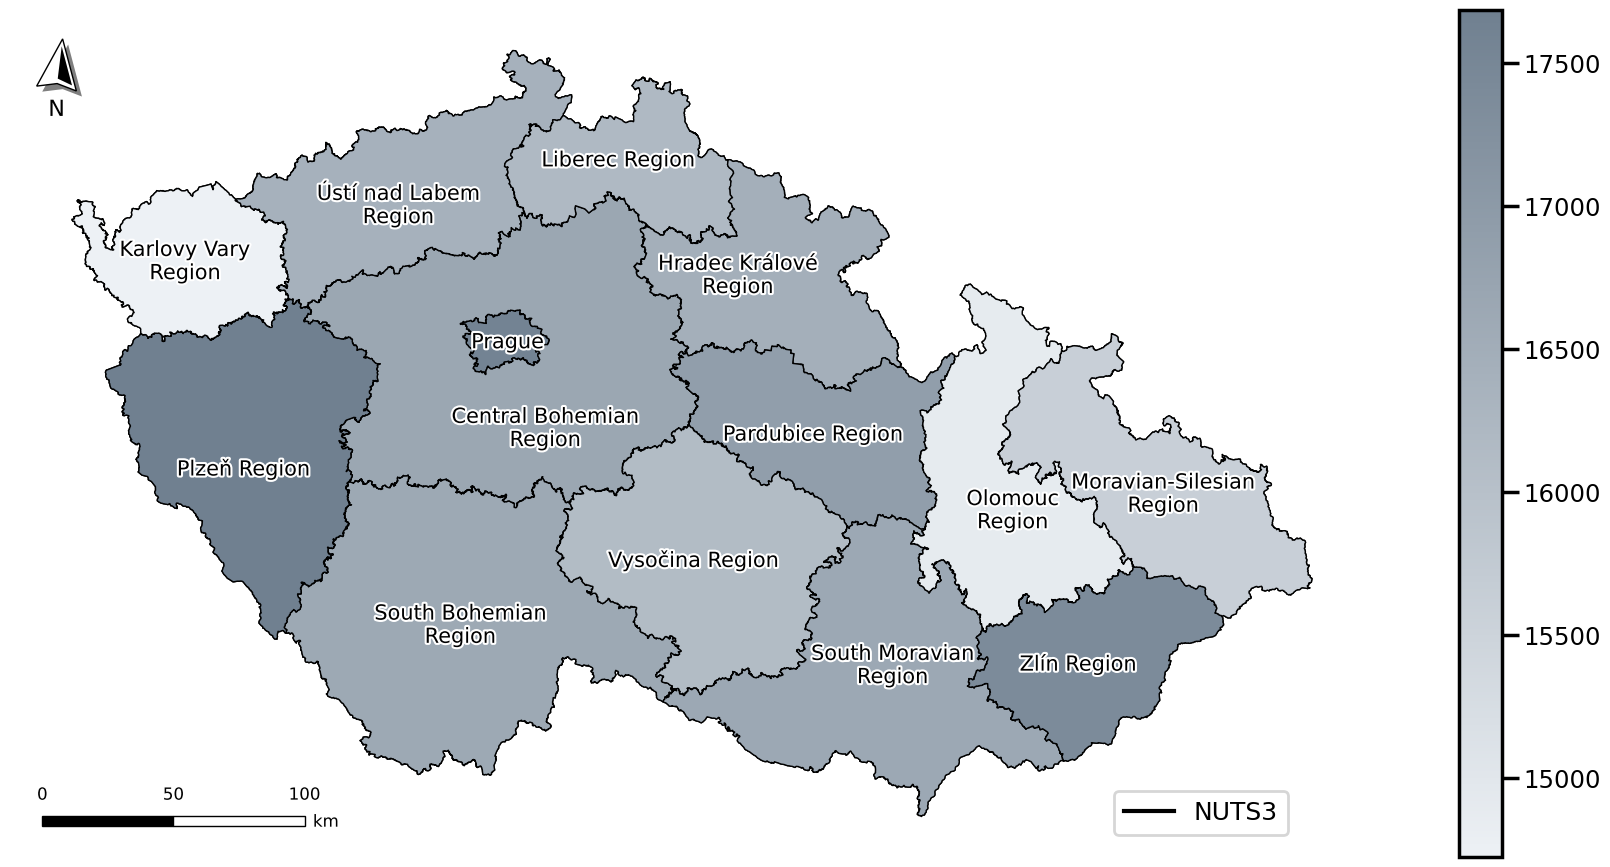

In [228]:
ax = kraje_polygony.plot(facecolor="none",   figsize=(22,11), edgecolor="black", linewidth=1)
kraj.plot(ax=ax, column="deto_decil_na_mesic", legend=True,cmap=cmap_gr,edgecolors='black', linewidth=1)
ax.set_axis_off()

patches = []

line_patch = Line2D([0], [0], color='black', linewidth=3, label='NUTS3')
patches.append(line_patch)

for idx, row in kraj.iterrows():
    x, y = row.geometry.representative_point().coords[0]

    # Apply offset if exists
    dx, dy = offsets.get(row['label'], (0, 0))
    x += dx
    y += dy

    label = row['label']  # your multi-line label
    txt = ax.text(
        x, y,
        label,
        ha='center',
        va='center',
        fontsize=15,
        color='black',
        path_effects=[PathEffects.withStroke(linewidth=3, foreground="white")],

    )


ax.legend(handles=patches, 
                fontsize=18, 
                title_fontsize=28,    
                loc='center left',          
                bbox_to_anchor=(0.8, 0.05)  )

scale_bar(
    ax, location="lower left", style="boxes", bar={"projection": skolky_body.crs, "unit": "km"}
)
north_arrow(
    ax, location="upper left", rotation={"crs": skolky_body.crs, "reference": "center"}
)
plt.savefig("map.png", dpi=300, bbox_inches="tight")


In [227]:
kraj[["NAZEV", "deto_decil_na_mesic"]]

,NAZEV,deto_decil_na_mesic
0,Prague,17596
1,Central Bohemian Region,16673
2,South Bohemian Region,16620
3,Plzeň Region,17686
4,Karlovy Vary Region,14725
5,Ústí nad Labem Region,16409
6,Liberec Region,16204
7,Hradec Králové Region,16452
8,Pardubice Region,16903
9,Vysočina Region,16115


In [222]:
kraj[ "deto_decil_na_mesic"].std()

890.4840269189572

In [176]:

from matplotlib.colors import LinearSegmentedColormap

cmap_teal= LinearSegmentedColormap.from_list("custom_teal", ["#DCECED", "#007A87"])
cmap_sage= LinearSegmentedColormap.from_list("custom_teal", ["#DCECDE", "#64966F"])
cmap_gr= LinearSegmentedColormap.from_list("custom_teal", ["#EDF1F5", "#708090"])
cmap_y= LinearSegmentedColormap.from_list("custom_teal", ["#FDF6E3", "#DAA105"])

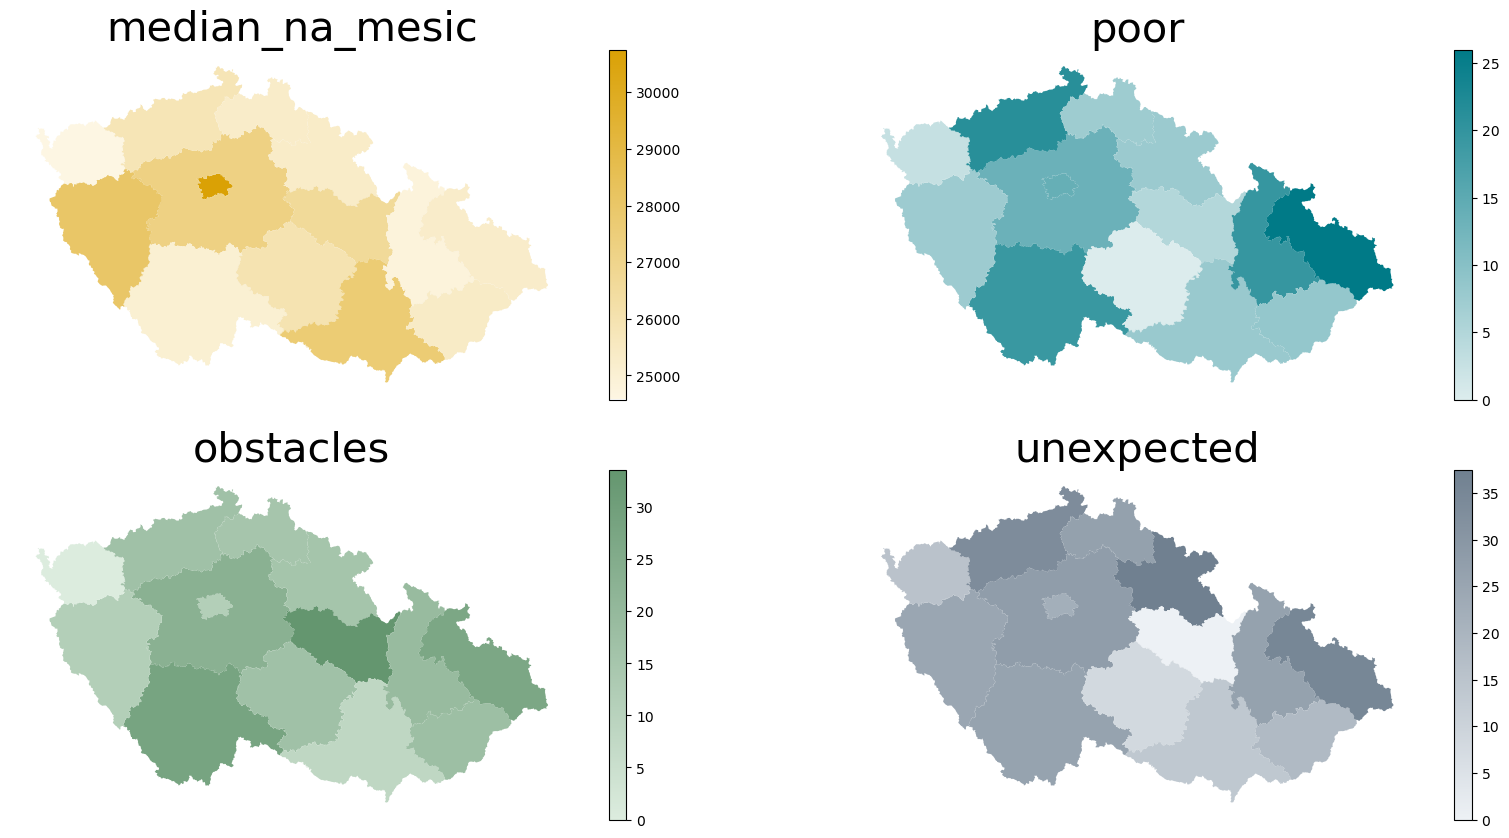

In [173]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
  
kraj.plot(column="deti_median_na_mesic", ax=axes[0, 0], cmap=cmap_y, legend=True)
axes[0, 0].set_title("median_na_mesic", fontsize=30)
axes[0, 0].set_axis_off()

kraj.plot(column="poor", ax=axes[0, 1], cmap=cmap_teal, legend=True)
axes[0, 1].set_title("poor", fontsize=30)
axes[0, 1].set_axis_off()

kraj.plot(column="obstacles", ax=axes[1, 0], cmap=cmap_sage, legend=True)
axes[1, 0].set_title("obstacles", fontsize=30)
axes[1, 0].set_axis_off()

kraj.plot(column="unexpected", ax=axes[1, 1], cmap=cmap_gr, legend=True)
axes[1, 1].set_title("unexpected", fontsize=30)
axes[1, 1].set_axis_off()